# Assignments - Numerical greeks

1. Introduce two class variables in Pricer that store the finite difference method (forward, backward, central) to be used in numerical greek calculation, and whether the bump size is absolute or relative. Create two Enums to store the labels. Implement all combinations for delta and gamma calculation.<br>Compare greeks using the analytic and the finite difference approximation on a set of European options and visualize the numerical error. Compare absolute and relative bumping and suggest optimal bump sizes. **(15 points)**

In [2]:
# Add current folder and QuantCourseBP folder to syspath to import modules
import sys
from pathlib import Path
current = Path(Path().resolve())
sys.path.append(str(current))
sys.path.append(str(current.parents[2]))

from src.market_data import *
from pricer import *

# Initialize market data
MarketData.initialize()

In [149]:
und = Stock.BLUECHIP_BANK
put_call = PutCallFwd.CALL
ls = LongShort.LONG
strk = MarketData.get_spot()[und] / 1.0  # at-the-money strike i.e. strike = spot price
exp = 0.5

option = EuropeanContract(und, put_call, ls, strk, exp)

model = FlatVolModel(und)

In [150]:
MarketData.get_spot()[und]

130.17

In [4]:
fwd_pricer = EuropeanAnalyticPricer(option, model, Params())
print(fwd_pricer.calc_delta(GreekMethod.ANALYTIC))
print(fwd_pricer.calc_delta(GreekMethod.BUMP))

0.588666805544619
0.5886143267684252


In [102]:
import matplotlib.pyplot as plt
import numpy as np

def delta_gamma_plotter(bumps_delta, bumps_gamma, deltas, gammas, delta_analytic, gamma_analytic):
    # Set a clean style
    plt.style.use('seaborn-v0_8-muted')
    
    # Create a 2x2 grid with shared x-axes for alignment
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    ((ax1, ax2), (ax3, ax4)) = axes

    # --- DELTA PLOTS ---
    # Top Left: Values
    ax1.plot(bumps_delta, deltas, label='Numerical', marker='.', markersize=4)
    ax1.axhline(delta_analytic, color='red', linestyle='--', alpha=0.7, label='Analytic')
    ax1.set_title('Delta Value', fontweight='bold')
    ax1.set_ylabel('Delta ($\Delta$)')
    ax1.legend()

    # Bottom Left: Error
    ax3.plot(bumps_delta, deltas - delta_analytic, color='purple', label='Error')
    ax3.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    ax3.set_title('Delta Error (Numerical - Analytic)', fontsize=10)
    ax3.set_ylabel('Difference')
    ax3.set_xlabel('Bump Size ($h$)')

    # --- GAMMA PLOTS ---
    # Top Right: Values
    ax2.plot(bumps_gamma, gammas, label='Numerical', color='green', marker='.', markersize=4)
    ax2.axhline(gamma_analytic, color='red', linestyle='--', alpha=0.7, label='Analytic')
    ax2.set_title('Gamma Value', fontweight='bold')
    ax2.set_ylabel('Gamma ($\Gamma$)')
    ax2.legend()

    # Bottom Right: Error
    ax4.plot(bumps_gamma, gammas - gamma_analytic, color='orange', label='Error')
    ax4.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    ax4.set_title('Gamma Error (Numerical - Analytic)', fontsize=10)
    ax4.set_ylabel('Difference')
    ax4.set_xlabel('Bump Size ($h$)')

    # Apply Log Scale to X-axis (crucial for seeing small bumps)
    for ax in axes.flat:
        ax.set_xscale('log')
        ax.grid(True, which="both", ls="-", alpha=0.2)

    plt.tight_layout()
    plt.show()

In [103]:
def bump_test(underlying, strike, put_call, long_short, finitemethod, bumpsizemethod, rel_bump_min_delta, rel_bump_max_delta, 
             rel_bump_min_gamma, rel_bump_max_gamma):
    option = EuropeanContract(underlying, put_call, long_short, strike, expiry)
    model = FlatVolModel(underlying)
    pricer = EuropeanAnalyticPricer(option, model, Params())
    
    pricer.finitemethod = finitemethod
    pricer.bumpsizemethod = bumpsizemethod
    
    if bumpsizemethod == BumpSizeMethod.RELATIVE:
        bumps_delta = np.linspace(rel_bump_min_delta, rel_bump_max_delta, 100)
        bumps_gamma = np.linspace(rel_bump_min_gamma, rel_bump_max_gamma, 100)

    elif bumpsizemethod == BumpSizeMethod.ABSOLUTE:
        bumps_delta = 100 * np.linspace(rel_bump_min_delta, rel_bump_max_delta, 100)
        bumps_gamma = 100 * np.linspace(rel_bump_min_gamma, rel_bump_max_gamma, 100)

    deltas = np.empty(len(bumps_delta))
    gammas = np.empty(len(bumps_gamma))

    for i in range(0, len(bumps_delta)):
        pricer.relative_bump_size = bumps_delta[i]
        deltas[i] = pricer.calc_delta(GreekMethod.BUMP)
        
    for i in range(0, len(bumps_gamma)):
        pricer.relative_bump_size = bumps_gamma[i]
        gammas[i] = pricer.calc_gamma(GreekMethod.BUMP)

    delta_analytic = pricer.calc_delta(GreekMethod.ANALYTIC)
    gamma_analytic = pricer.calc_gamma(GreekMethod.ANALYTIC)
    
    delta_gamma_plotter(bumps_delta, bumps_gamma, deltas, gammas, delta_analytic, gamma_analytic)

In [133]:
und1 = Stock.BLUECHIP_BANK
strk1 = MarketData.get_spot()[und] / 1.0

und2 = Stock.MONEY_MALL
strk2 = MarketData.get_spot()[und] / 1.0

put_call = PutCallFwd.CALL
ls = LongShort.LONG
expiry = 0.5

# Central, Relative

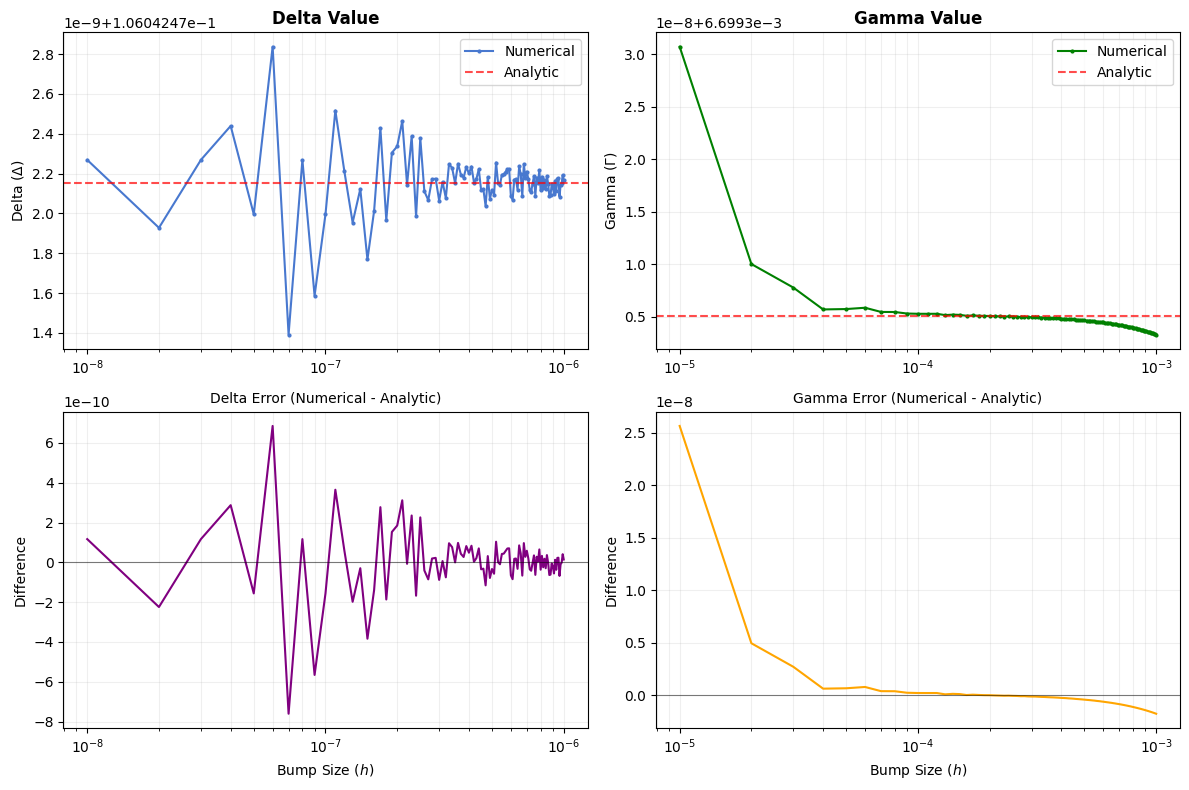

In [134]:
bump_test(und1, strk1, put_call, ls, FiniteMethod.CENTRAL, BumpSizeMethod.RELATIVE, 1e-8, 1e-6, 1e-5, 1e-3)

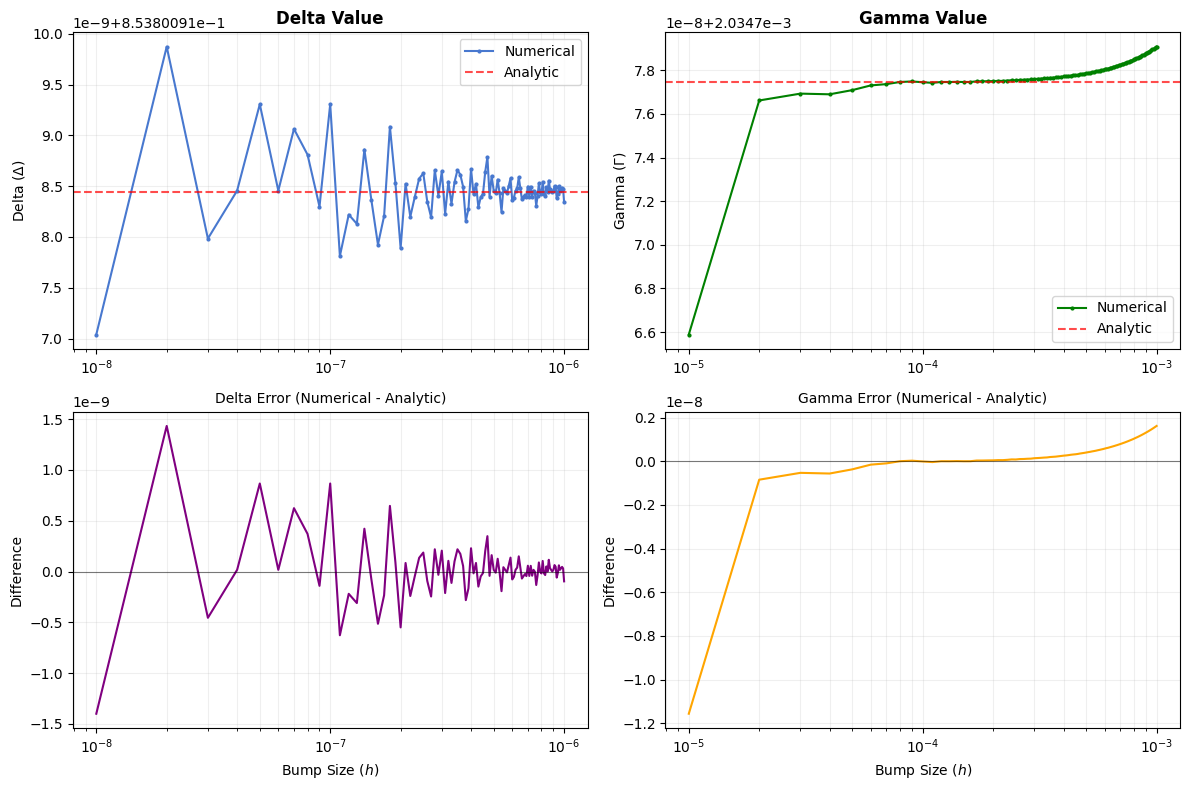

In [124]:
bump_test(und2, strk2, put_call, ls, FiniteMethod.CENTRAL, BumpSizeMethod.RELATIVE, 1e-8, 1e-6, 1e-5, 1e-3)

#### Suggested optimal relative bump size:

- for delta: 1e-7
- for gamma: 1e-4

# Forward, Relative

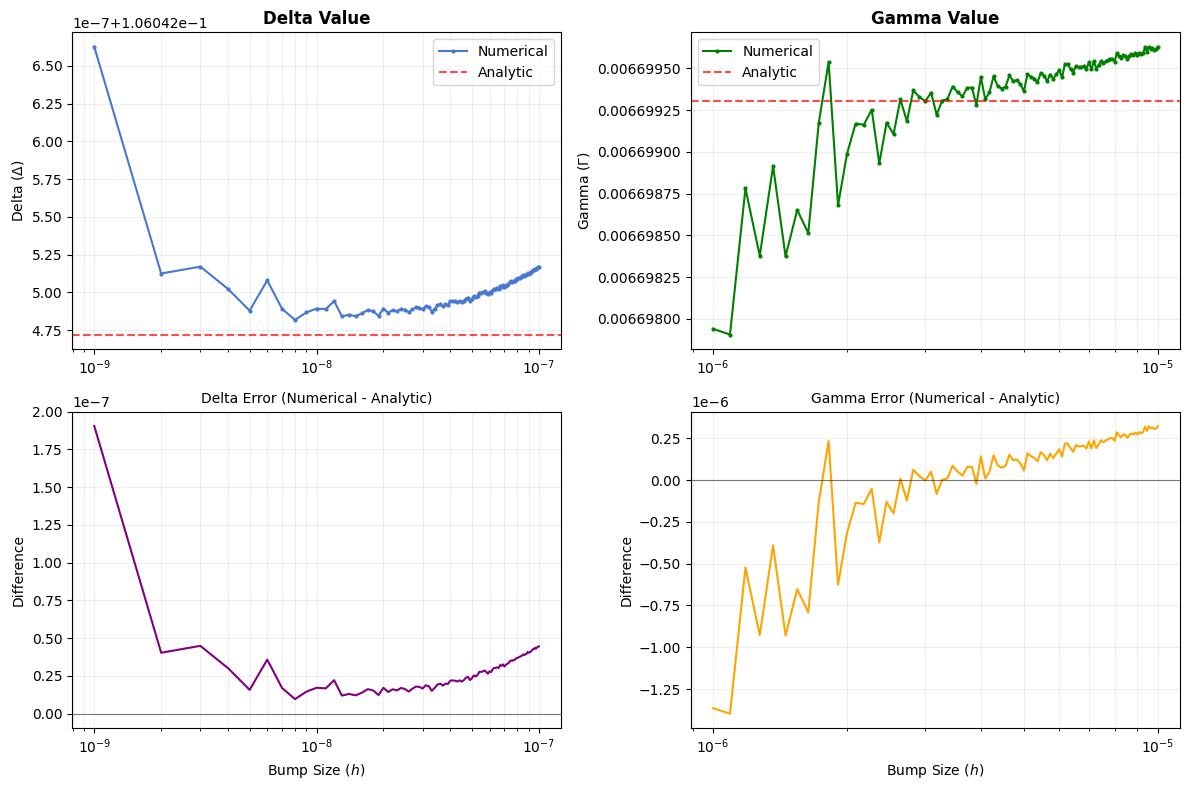

In [120]:
bump_test(und1, strk1, put_call, ls, FiniteMethod.FORWARD, BumpSizeMethod.RELATIVE, 1e-9, 1e-7, 1e-6, 1e-5)

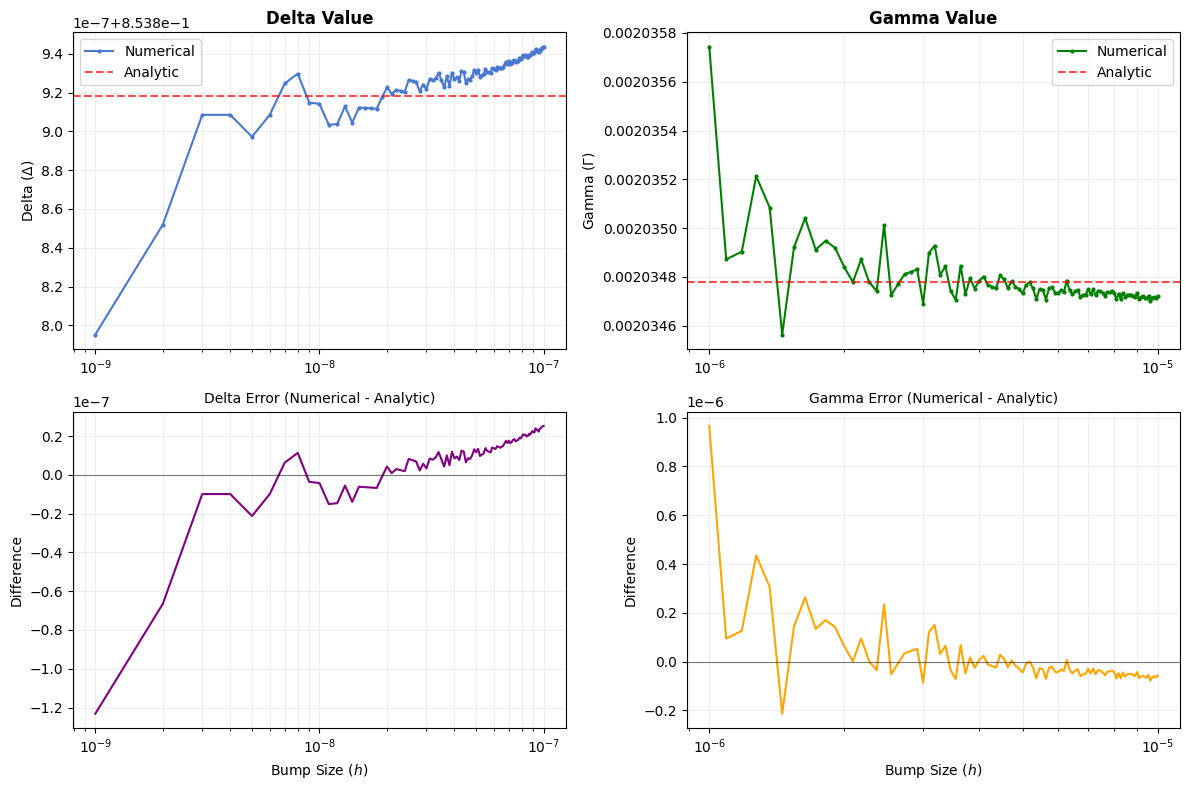

In [121]:
bump_test(und2, strk2, put_call, ls, FiniteMethod.FORWARD, BumpSizeMethod.RELATIVE, 1e-9, 1e-7, 1e-6, 1e-5)

#### Suggested optimal relative bump size:

- for delta: 1e-8
- for gamma: 1e-5 / 5

Note: Forward method visibly performs worse than Central, as can be seen particularly in the case of und1: bump method overestimates delta for all bump sizes using Forward method.

# Backward, Relative

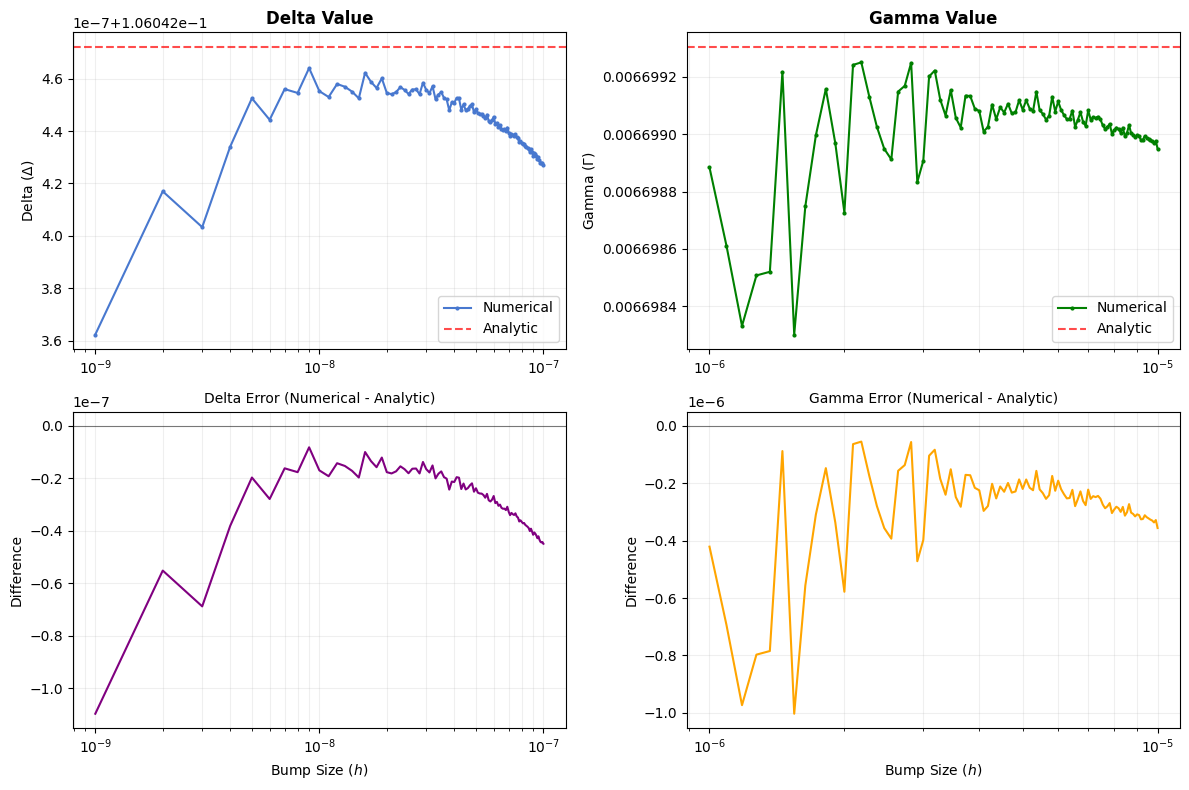

In [125]:
bump_test(und1, strk1, put_call, ls, FiniteMethod.BACKWARD, BumpSizeMethod.RELATIVE, 1e-9, 1e-7, 1e-6, 1e-5)

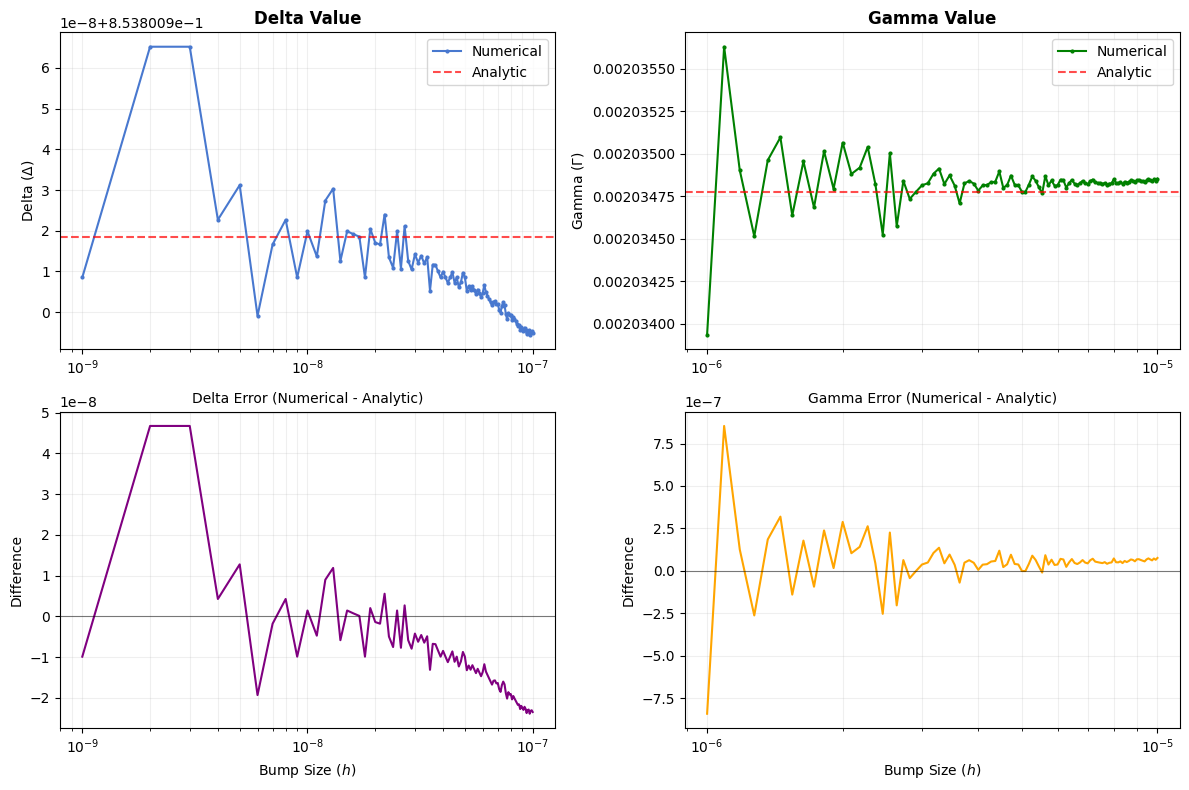

In [126]:
bump_test(und2, strk2, put_call, ls, FiniteMethod.BACKWARD, BumpSizeMethod.RELATIVE, 1e-9, 1e-7, 1e-6, 1e-5)

#### Suggested optimal relative bump size:

- for delta: 1e-8
- for gamma: 1e-5 / 5

Note: Backward method visibly performs worse than Central, as can be seen particularly in the case of und1: bump method underestimates delta and gamma for all bump sizes using Backward method.

# Central, Absolute

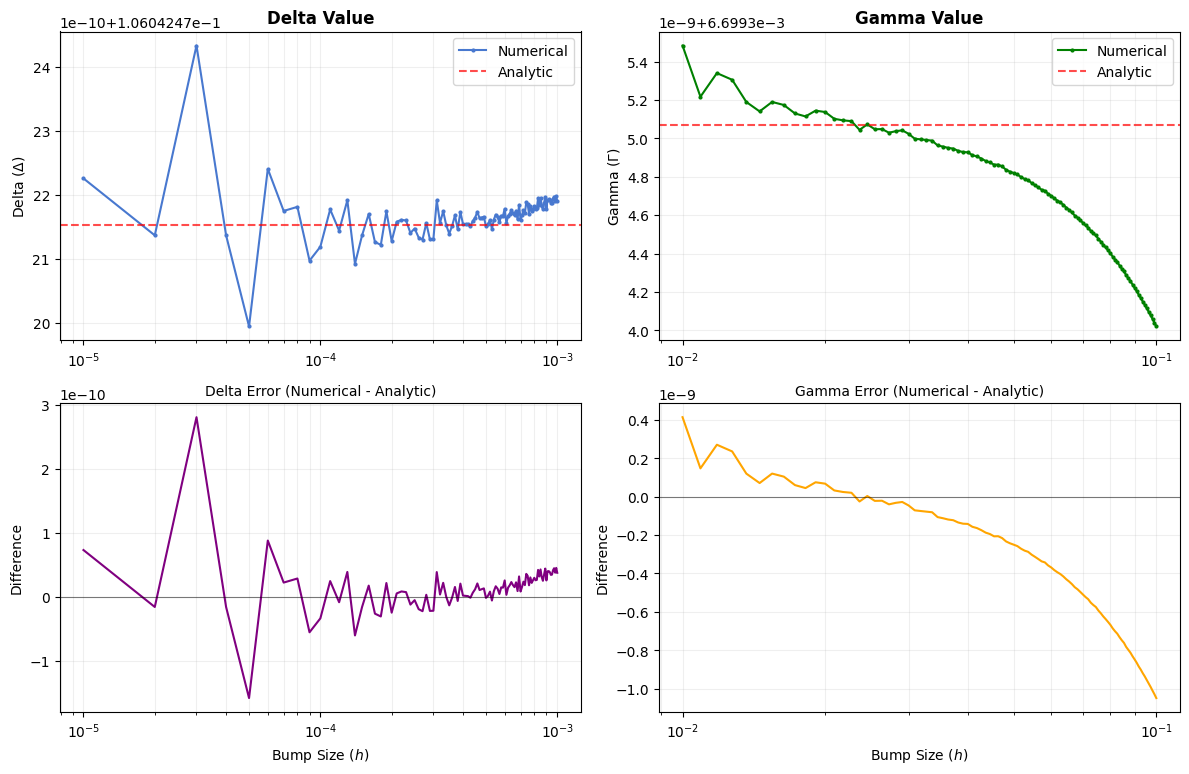

In [140]:
bump_test(und1, strk1, put_call, ls, FiniteMethod.CENTRAL, BumpSizeMethod.ABSOLUTE, 1e-7, 1e-5, 1e-4, 1e-3)

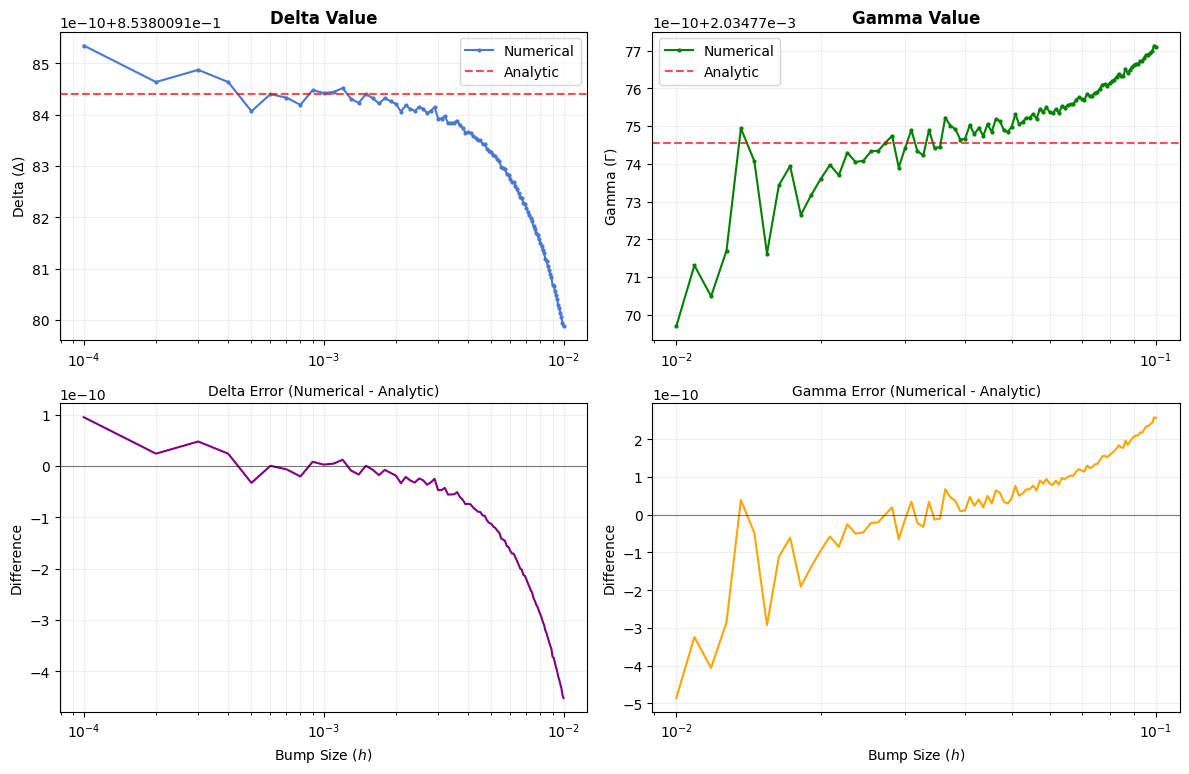

In [139]:
bump_test(und2, strk2, put_call, ls, FiniteMethod.CENTRAL, BumpSizeMethod.ABSOLUTE, 1e-6, 1e-4, 1e-4, 1e-3)

#### Suggested optimal absolute bump size:

- for und1:
    - for delta: 1e-4
    - for gamma: 1e-1 / 5

- for und2:
    - for delta: 1e-3
    - for gamma: 1e-1 / 5

# Conclusion

A clear disadvantage of using absolute bump sizes is that the optimum will change based on the spot rate of the underlying, making it difficult to give an accurate estimation of derivatives across multiple assets.

In comparison, using relative bump sizes means that optimal values stay relatively consistent across assets. When using relative bump sizes, the Central method outperforms Forward and Backward methods. Suggested optimal bump sizes for Central method:

- for delta: 1e-7
- for gamma: 1e-4